## Exercise 04 : Histogram

In [1]:
import pandas as pd 
import sqlite3
import matplotlib.pyplot as plt

### Make a connection to the database

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

### Run query

In [3]:
query = """
SELECT
   uid, DATETIME(timestamp) AS commits
FROM checker
WHERE uid LIKE 'user%';
"""
df = pd.read_sql(sql=query, con=conn, parse_dates='commits')
df

,uid,commits
0,user_4,2020-04-17 05:19:02
1,user_4,2020-04-17 05:22:35
2,user_4,2020-04-17 05:22:45
3,user_4,2020-04-17 05:34:14
4,user_4,2020-04-17 05:34:24
...,...,...
3202,user_1,2020-05-21 20:19:06
3203,user_1,2020-05-21 20:22:41
3204,user_1,2020-05-21 20:22:41
3205,user_1,2020-05-21 20:37:00


### Create dataframe with date, weekday and hour columns

In [4]:
df['date'] = df['commits'].dt.date
df['weekday'] = df['commits'].dt.dayofweek.apply(lambda x: 'weekend' if x in {5, 6} else 'working_day')
df['hour'] = pd.cut(x=df['commits'].dt.hour,
                       bins=list(range(25)),
                       labels=list(map(str, range(24))),
                       right=False, include_lowest=True)
df

,uid,commits,date,weekday,hour
0,user_4,2020-04-17 05:19:02,2020-04-17,working_day,5
1,user_4,2020-04-17 05:22:35,2020-04-17,working_day,5
2,user_4,2020-04-17 05:22:45,2020-04-17,working_day,5
3,user_4,2020-04-17 05:34:14,2020-04-17,working_day,5
4,user_4,2020-04-17 05:34:24,2020-04-17,working_day,5
...,...,...,...,...,...
3202,user_1,2020-05-21 20:19:06,2020-05-21,working_day,20
3203,user_1,2020-05-21 20:22:41,2020-05-21,working_day,20
3204,user_1,2020-05-21 20:22:41,2020-05-21,working_day,20
3205,user_1,2020-05-21 20:37:00,2020-05-21,working_day,20


In [5]:
df['weekday'][df['weekday'] == 'working_day'].count()

np.int64(2037)

In [6]:
df['weekday'][df['weekday'] == 'weekend'].count()

np.int64(1170)

### Group entries by date and hour

In [7]:
df = df.iloc[:, 2:].groupby(['date', 'hour'], observed=True, as_index=False).value_counts()
df

,date,hour,weekday,count
0,2020-04-17,5,working_day,13
1,2020-04-17,11,working_day,8
2,2020-04-17,12,working_day,2
3,2020-04-18,7,weekend,1
4,2020-04-18,13,weekend,5
...,...,...,...,...
283,2020-05-21,16,working_day,4
284,2020-05-21,17,working_day,1
285,2020-05-21,18,working_day,2
286,2020-05-21,19,working_day,8


### Create pivot table with total amount of commits count

In [8]:
df = df.pivot_table(index='hour', columns='weekday', values='count', aggfunc='sum', dropna=False, fill_value=0, observed=False)
df

weekday,weekend,working_day
hour,,
0,6,6
1,6,0
2,0,0
3,1,2
4,0,0
5,2,15
6,0,3
7,16,31
8,28,37


### Сreate a histogram

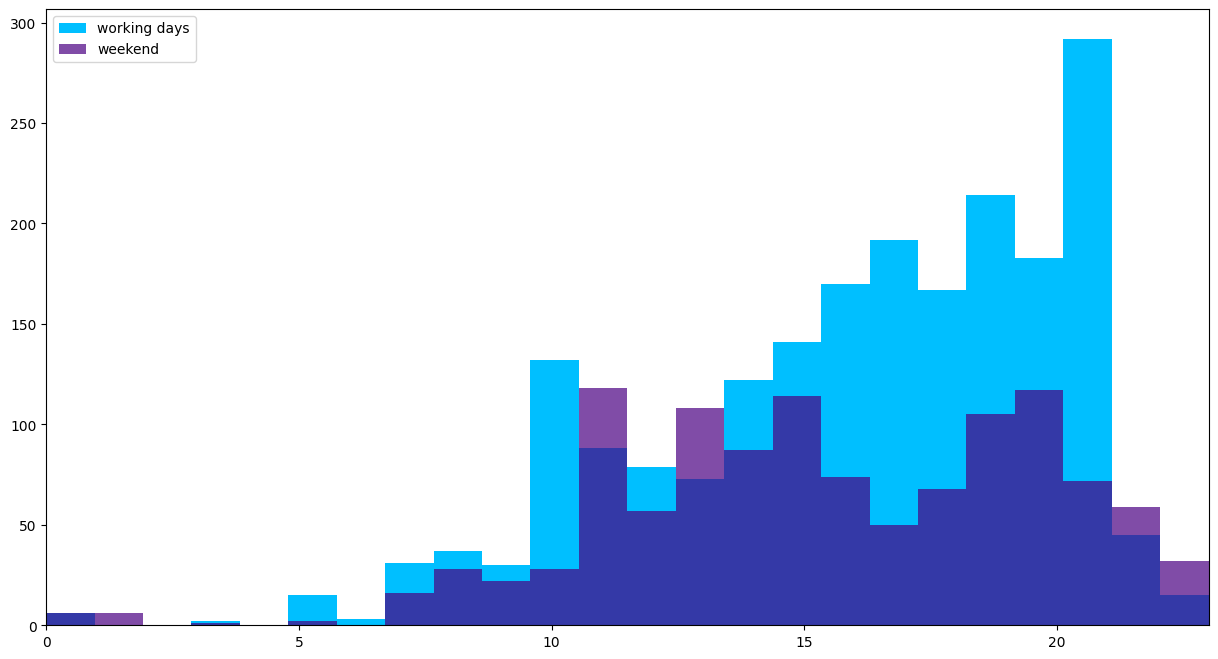

In [9]:
x = list(range(len(df)))
plt.figure(figsize=(15, 8))
plt.xlim(left=x[0], right=x[-1])
plt.hist(x, weights=df["working_day"].values, bins=len(df), color="DeepSkyBlue", label="working days")
plt.hist(x, weights=df['weekend'].values, bins=len(df), alpha=0.7, color="Indigo", label="weekend")
plt.legend()
plt.show()

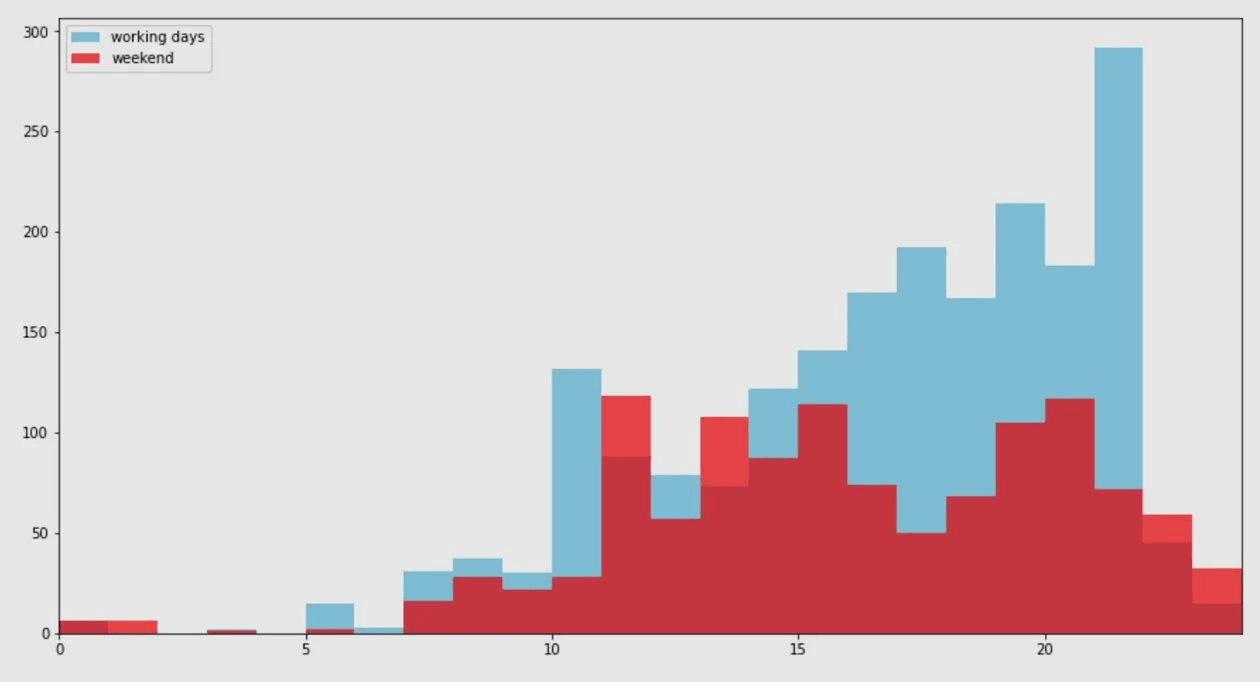

In [10]:
conn.close()

### “Are there hours when the total number of commits was higher on weekends than on working days?”

#### Answer: **11, 13, 22, 23**